# HNN likelihood estimation with PyMC

In this tutorial, we will estimate the same input arrival time $\mu$ and pyramidal AMPA weight $w_{\mathrm{pyr}}$ from an HNN dipole waveform. See [the NPE notebook](hnn-npe.ipynb) for the circuit, priors, observables, and simulation code. Here BayesFlow learns 

$$q
_\phi(\mathrm{dipole}\mid\mu,w_{\mathrm{pyr}}),
$$

then PyMC combines this neural likelihood with the priors using NUTS, following the [BayesFlow NLE tutorial](https://bayesflow.org/v2.0.14/_examples/Likelihood_Estimation.html).

Run `uv sync --extra nle` before selecting the repo's kernel. We reuse the offline HNN data, so no NEURON installation is needed.

In [ ]:
import numpy as np

import arviz as az
import pymc as pm

import bayesflow as bf
from bayesflow.wrappers.pymc import NeuralDistribution

from tutorials.helpers import hnn

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.


INFO:bayesflow:Using backend 'jax'


In [ ]:
train, validation, test = hnn.load_dataset()

## Train the likelihood offline

NLE simply reverse the NPE variable roles: the complete 66-point dipole vector is the inference target, and timing plus log-weight are conditions. Concretely: 
- A spline flow models their joint density
- We do not assume independent time points 
- PyMC will use the same log-weight coordinates as the trained network

In [ ]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .log("weight_pyr")
    .concatenate(["mu", "weight_pyr"], into="inference_conditions")
    .rename("dipole", "inference_variables")
)

workflow = bf.BasicWorkflow(
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(
        depth=2,
        transform="spline",
        subnet_kwargs={"widths": (128, 128), "dropout": 0.05},
    ),
    standardize="all",
    initial_learning_rate=5e-4
)

history = workflow.fit_offline(
    train,
    validation_data=validation,
    epochs=500,
    batch_size=128
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.


INFO:bayesflow:Building on a test batch.


INFO:bayesflow:Training completed in 2.99 minutes.


The loss plot compares training and held-out validation loss. A decreasing training loss with increasing validation loss indicates overfitting.

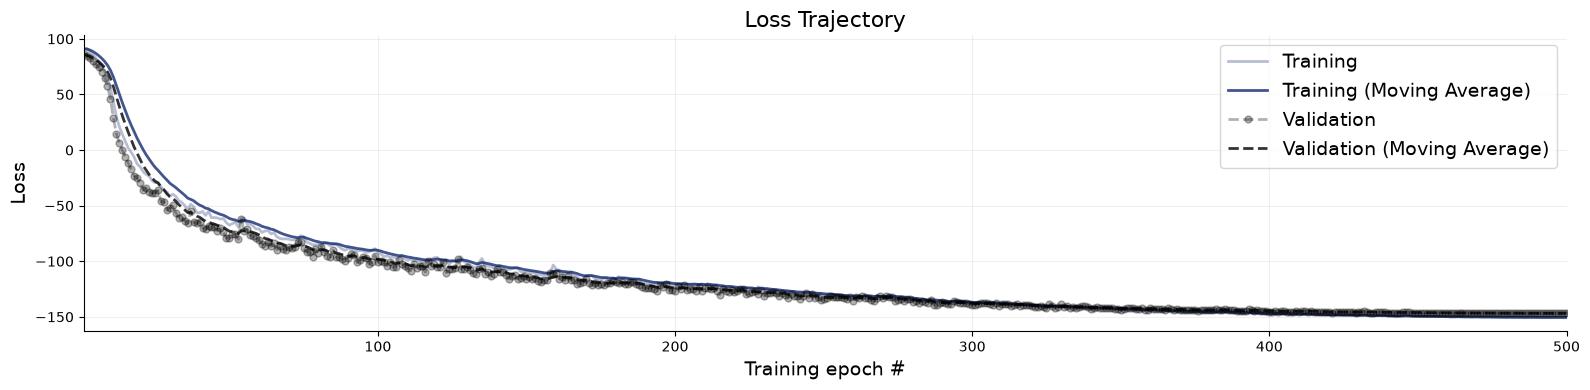

In [3]:
fig = bf.diagnostics.loss(history)

## Infer parameters for one held-out waveform

The plot shows the noisy current dipole (nAm) over time (ms) for the first test simulation. We keep its parameters aside as ground truth.

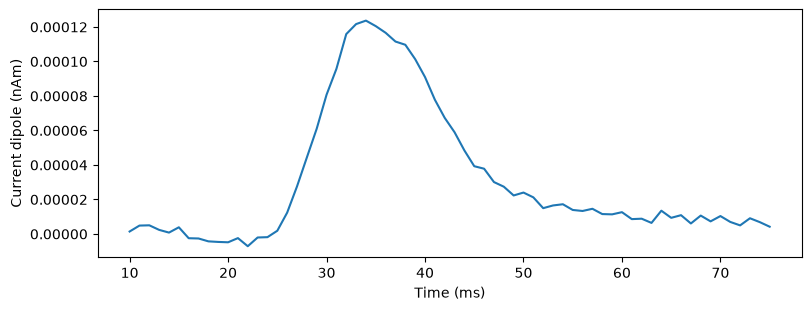

In [ ]:
case = {key: values[:1] for key, values in test.items()}
mu_true = case["mu"][0, 0]
weight_true = case["weight_pyr"][0, 0]

fig = hnn.plot_waveforms(case, n_examples=1)

`NeuralDistribution` supplies the learned likelihood and gradients to PyMC. `observed` has shape `(1, 66)`: one complete dipole waveform. We use the NPE priors and run four chains with 1,000 tuning steps and 1,000 posterior draws each.

In [ ]:
neural_dist = NeuralDistribution(
    approximator=workflow.approximator,
    param_names=["mu", "log_weight_pyr"],
)

with pm.Model() as model:

    # Priors
    mu = pm.Uniform("mu", lower=25, upper=45)
    log_weight_pyr = pm.Uniform(
        "log_weight_pyr",
        lower=np.log(1e-4),
        upper=np.log(8e-4),
    )

    # Deterministic transform
    weight_pyr = pm.Deterministic("weight_pyr", pm.math.exp(log_weight_pyr))

    # Neural likelihood
    obs = neural_dist("obs", mu=mu, log_weight_pyr=log_weight_pyr, observed=case["dipole"])

    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        nuts_sampler="pymc",
        random_seed=42,
    )

INFO:pymc.sampling.mcmc:Initializing NUTS using jitter+adapt_diag...


INFO:pymc.sampling.mcmc:Sequential sampling (4 chains in 1 job)


INFO:pymc.sampling.mcmc:NUTS: [mu, log_weight_pyr]


INFO:pymc.sampling.mcmc:Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.


## Inspect the posterior and ground truth

The posterior histograms show the MCMC draws, with the true simulated parameters marked as reference values and 90% highest-density intervals. Check whether these intervals contain the ground truth. This single example illustrates recovery; it cannot establish calibration across datasets.

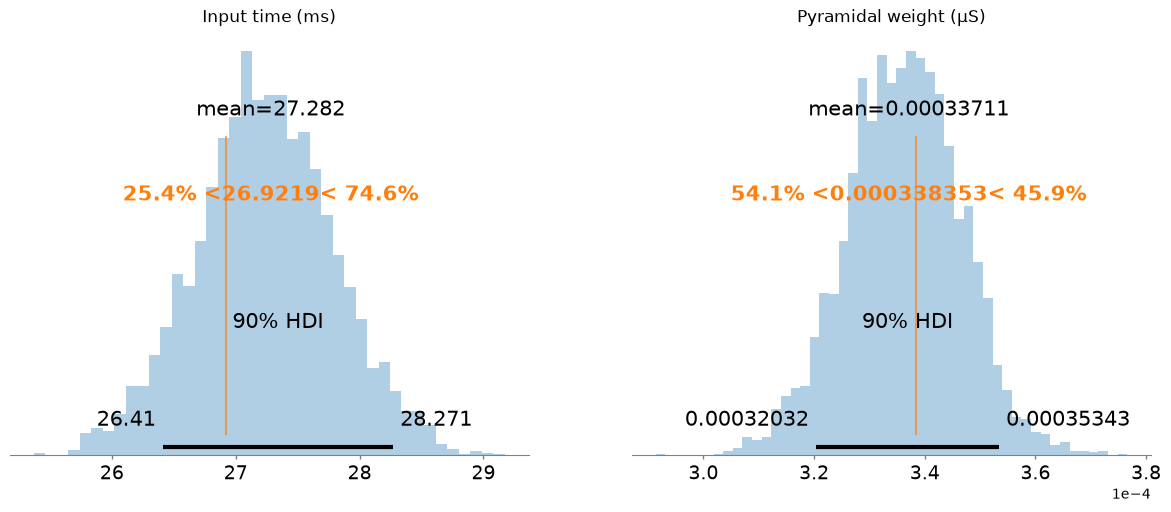

In [6]:
axes = az.plot_posterior(
    trace,
    var_names=["mu", "weight_pyr"],
    kind="hist",
    bins="auto",
    ref_val=[mu_true, weight_true],
    hdi_prob=0.9,
    round_to=5,
)
axes[0].set_title("Input time (ms)")
axes[1].set_title("Pyramidal weight (µS)")
axes[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

The trace plot compares the four chains over sampling iterations. The summary reports effective sample size and R-hat; well-mixed chains should agree and have R-hat near 1.

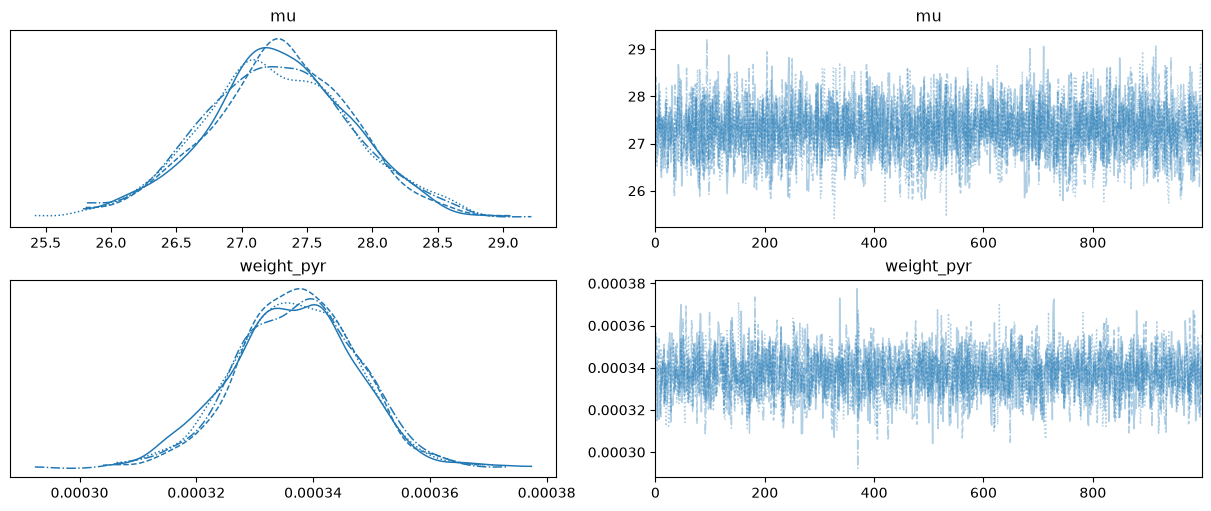

In [7]:
axes = az.plot_trace(
    trace,
    var_names=["mu", "weight_pyr"],
    figsize=(12, 5),
    backend_kwargs={"layout": "constrained"},
)

In [8]:
az.summary(trace, var_names=["mu", "weight_pyr"], hdi_prob=0.9, round_to=5)

,mean,sd,hdi_5%,hdi_95%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,27.28212,0.55832,26.41005,28.27105,0.01025,0.00967,2960.67533,1733.12998,1.00137
weight_pyr,0.00034,0.00001,0.00032,0.00035,0.00000,0.00000,2562.27707,2079.02535,1.00148


Both 90% HDIs contain the ground truth; the four chains have R-hat about 1.00 and no divergences.